### 데이터 로드

In [1]:
import pandas as pd

df = pd.read_csv('news_lda_result.csv')
topic_press_ratio = pd.read_csv("press_topic_ratio.csv", index_col=0)


### 시각화 설정

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.font_manager as fm

# 경고 메시지 제거
warnings.filterwarnings("ignore")

# 그래프 스타일
sns.set_style("whitegrid")

# 한글 폰트 설정 (Windows)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

### 1️⃣ 전체 뉴스 토픽 분포

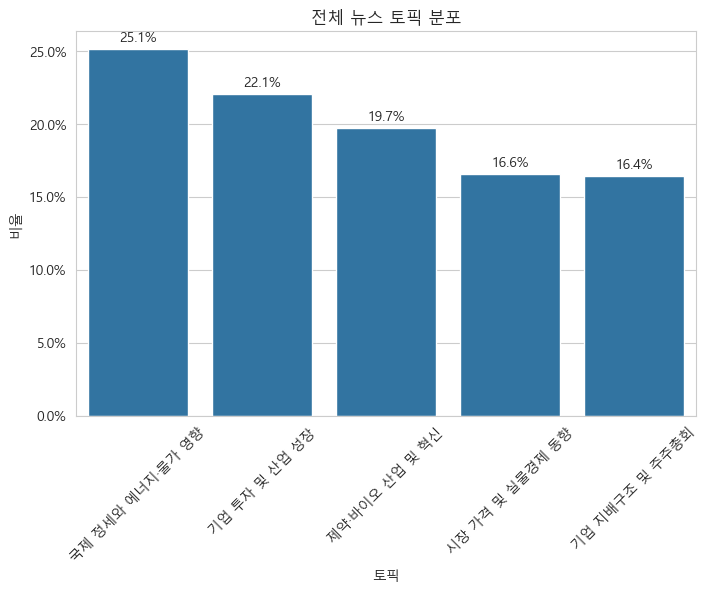

In [3]:
topic_distribution = df["topic_name"].value_counts(normalize=True)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=topic_distribution.index,
    y=topic_distribution.values
)

plt.xticks(rotation=45)
plt.title("전체 뉴스 토픽 분포")
plt.xlabel("토픽")
plt.ylabel("비율")

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(topic_distribution.values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha='center')

plt.show()

### 2️⃣ 언론사별 토픽 분포 (Stacked Bar)

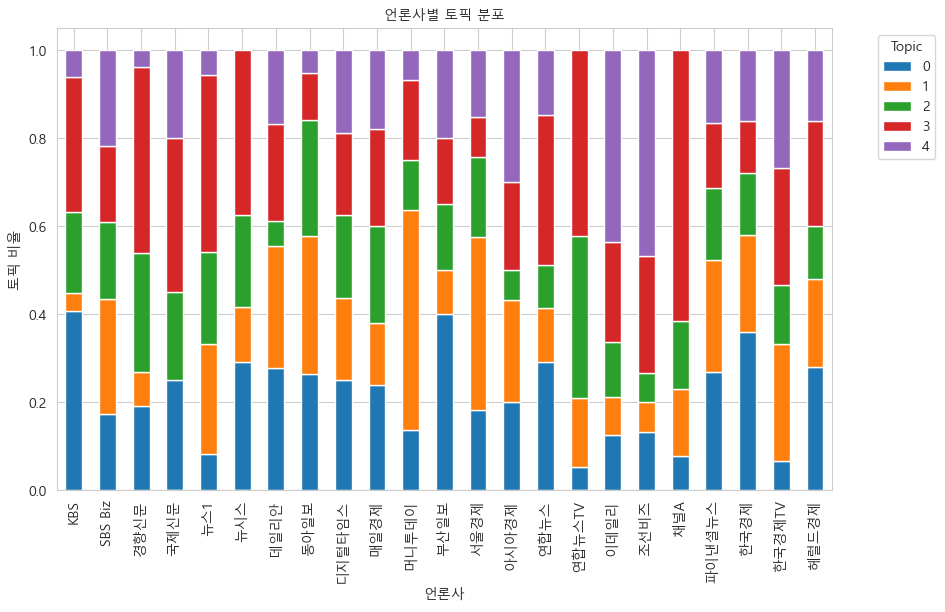

In [4]:
topic_press_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6))

plt.title("언론사별 토픽 분포", fontproperties=font_prop)
plt.xlabel("언론사", fontproperties=font_prop)
plt.ylabel("토픽 비율", fontproperties=font_prop)

plt.legend(title="Topic", bbox_to_anchor=(1.05,1))

plt.show()

### 3️⃣ 언론사 × 토픽 Heatmap

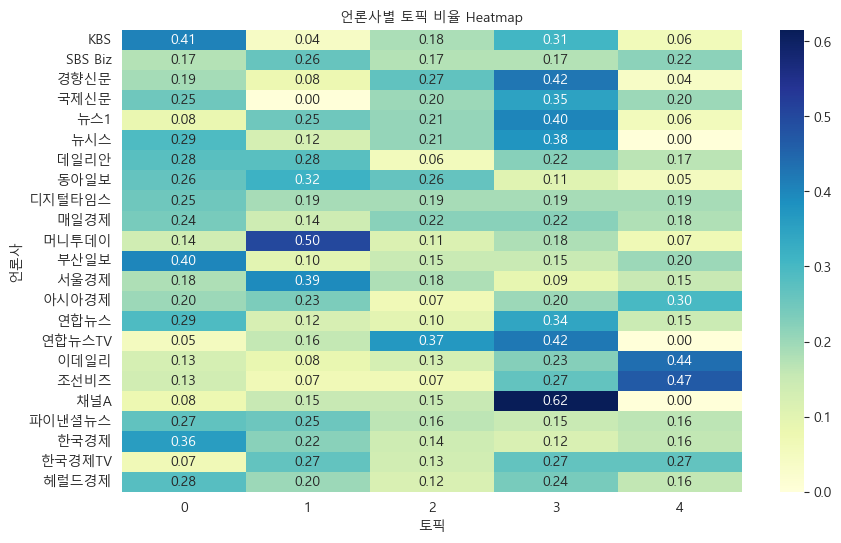

In [5]:
plt.figure(figsize=(10,6))

sns.heatmap(
    topic_press_ratio,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f")

plt.title("언론사별 토픽 비율 Heatmap", fontproperties=font_prop)
plt.xlabel("토픽", fontproperties=font_prop)
plt.ylabel("언론사", fontproperties=font_prop)

plt.show()